# Using GOAC for replicating randomized_distribution.py

This notebooks aims to show how GOAC can be used to replicate figure 2a/c from [Beneﬁcial redox activity paper](https://chemrxiv.org/doi/pdf/10.26434)

In [1]:
import sys

from gemdat.utils import DATA, SCRIPTS_DIR

sys.path.insert(0, str(SCRIPTS_DIR))

# Needs GOAC installed in this kernel's environment:
#   pip install GOAC --find-links https://github.com/GEMDAT-repos/GOAC/releases/expanded_assets/0.1.1
from goac_li3ycl3br3 import GOACSweep
from mlip_hull import HullBuilder

sweeping: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:05<00:00,  3.56 composition/s, x=9]


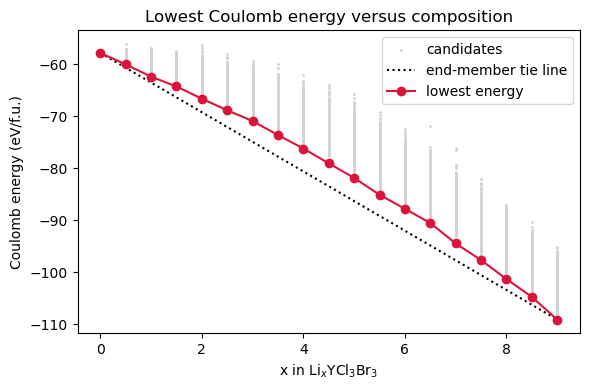

In [2]:
setup = GOACSweep(
    cif=DATA / 'Li3YCl3Br3-c2m.cif',
    x_min=0,
    x_max=9,
    x_step=0.5,
    samples=10000,
    solver='random',
    n_best=1,
    supercell=[2, 1, 2],
    extra_interstitials=True,
    quiet=True,
    progress=True,
)
result = setup.run()

In [3]:
result.summary()

  x      E_min (eV/f.u.)
   0.00         -57.880
   0.50         -60.082
   1.00         -62.435
   1.50         -64.320
   2.00         -66.669
   2.50         -68.887
   3.00         -70.966
   3.50         -73.649
   4.00         -76.246
   4.50         -79.087
   5.00         -81.889
   5.50         -85.122
   6.00         -87.822
   6.50         -90.548
   7.00         -94.475
   7.50         -97.679
   8.00        -101.311
   8.50        -104.752
   9.00        -109.101

/home/vikko/local_projects/GEMDAT/.venv_nix/lib/python3.14/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/vikko/local_projects/GEMDAT/.venv_nix/lib/python3.14/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /home/vikko/.cache/mace/20231210mace128L0_energy_epoch249model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


relaxing: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [23:31<00:00, 78.41s/ structure, best_x9-0.cif]


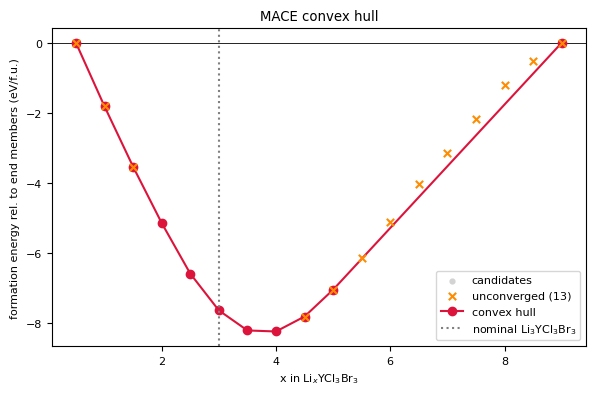

In [4]:
macesetup = HullBuilder(
    workdir=result.workdir,
    model='mace',
    mace_model='small',
    device='cpu',
    steps=100,
    relax_cell=False,
    reduction_aware=False,
    halide_samples=1,
    br_fraction=0.5,
    progress=True,
    quiet=True,
)
maceresult = macesetup.run()

In [5]:
maceresult.workdir
maceresult.summary()

  x      E_form (eV/f.u.)   on hull   converged
   0.50         0.000       *         NO
   1.00        -1.815       *         NO
   1.50        -3.536       *         NO
   2.00        -5.142       *         yes
   2.50        -6.586       *         yes
   3.00        -7.635       *         yes
   3.50        -8.208       *         yes
   4.00        -8.238       *         yes
   4.50        -7.812       *         NO
   5.00        -7.046       *         NO
   5.50        -6.151                 NO
   6.00        -5.111                 NO
   6.50        -4.033                 NO
   7.00        -3.152                 NO
   7.50        -2.187                 NO
   8.00        -1.199                 NO
   8.50        -0.532                 NO
   9.00         0.000       *         NO

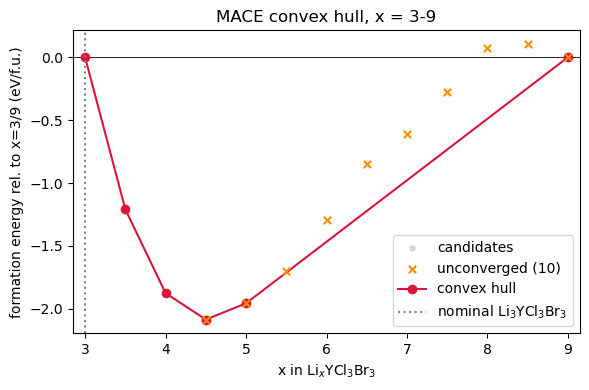

In [6]:
zoomresult = maceresult.restrict(xlim=[3, 9])
zoomresult.plot();

## Looking at the relaxed x = 3.5 structure

The relaxed geometries themselves are kept on the result, so the structure sitting on the
hull at x = 3.5 can be inspected with GEMDAT's 3D plot.

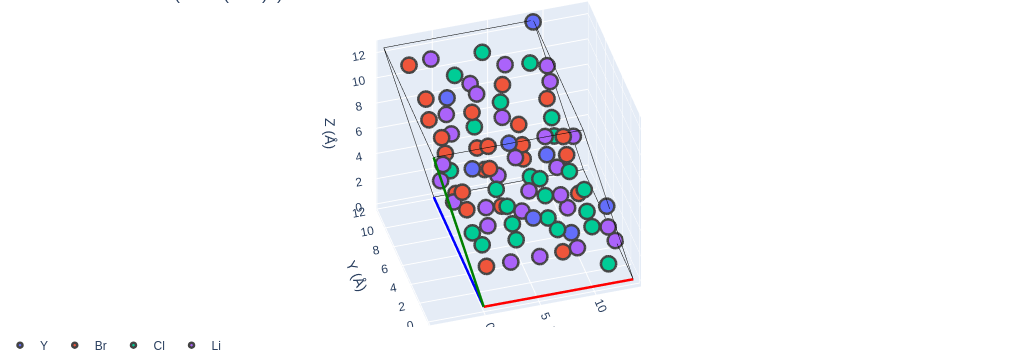

In [7]:
from pymatgen.io.ase import AseAtomsAdaptor

from gemdat.plots import plot_3d

relaxed = min(maceresult.results, key=lambda result: abs(result.x - 3.5))
structure = AseAtomsAdaptor.get_structure(relaxed.atoms)

plot_3d(
    structure=structure,
    title=f'Relaxed x = {relaxed.x:g} ({structure.composition.reduced_formula})',
)